# 01 — Carga de Datos

Descarga el dataset TBX11K desde Kaggle, mapea su estructura completa y construye
el DataFrame base con las rutas y etiquetas de las imágenes etiquetadas.

**Output:** `df_base` con columnas `image_path`, `class_name`, `label`, `ancho`, `alto`, `modo`.

In [1]:
import os
import shutil

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# El kaggle.json debe estar en la raíz del proyecto (carpeta padre de notebooks/)
KAGGLE_JSON = os.path.join(os.path.dirname(os.getcwd()), 'kaggle.json')
if not os.path.exists(KAGGLE_JSON):
    # Si se corre desde la raíz directamente
    KAGGLE_JSON = os.path.join(os.getcwd(), 'kaggle.json')

if IN_COLAB:
    from google.colab import files
    print('Sube tu kaggle.json:')
    files.upload()
    KAGGLE_JSON = 'kaggle.json'

if not os.path.exists(KAGGLE_JSON):
    raise FileNotFoundError(
        'No se encontró kaggle.json.\n'
        'Descárgalo desde kaggle.com → Settings → API → Create New Token\n'
        'y colócalo en la raíz del proyecto (cad-tbx11k/).'
    )

kaggle_dir = os.path.join(os.path.expanduser('~'), '.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
dest = os.path.join(kaggle_dir, 'kaggle.json')
if not os.path.exists(dest):
    shutil.copy(KAGGLE_JSON, dest)
    os.chmod(dest, 0o600)

print('kaggle.json configurado ✓')

kaggle.json configurado ✓


In [2]:
import kagglehub

path = kagglehub.dataset_download('usmanshams/tbx-11')
print(f'Dataset en: {path}')

c:\Users\estra\Desktop\Tuberculosis\cad-tbx11k\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset en: C:\Users\estra\.cache\kagglehub\datasets\usmanshams\tbx-11\versions\1


In [3]:
import random
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings('ignore')
random.seed(42)

In [4]:
DATA_ROOT  = os.path.join(path, 'TBX11K')
LABEL_MAP  = {'health': 0, 'sick': 1, 'tb': 2}
VALID_EXTS = ('.png', '.jpg', '.jpeg')

print(f'DATA_ROOT : {DATA_ROOT}')
print(f'Existe    : {os.path.exists(DATA_ROOT)}')

DATA_ROOT : C:\Users\estra\.cache\kagglehub\datasets\usmanshams\tbx-11\versions\1\TBX11K
Existe    : True


---
## 1. Estructura completa del dataset

Antes de cargar algo, se mapea todo lo que hay en `imgs/`.

- `health`, `sick`, `tb` — etiquetadas (train+val). Son las que se usan.
- `test` — sin etiqueta pública. Es la partición del challenge oficial.
- `extra` — datasets externos adicionales (Montgomery, Shenzhen, DA, DB), por ahora no los usaremos.

In [5]:
imgs_dir = Path(DATA_ROOT) / 'imgs'

resumen = []
for carpeta in sorted(imgs_dir.iterdir()):
    if not carpeta.is_dir():
        continue
    subcarpetas = [s for s in carpeta.iterdir() if s.is_dir()]
    if subcarpetas:
        for sub in sorted(subcarpetas):
            n = len([f for f in sub.iterdir() if f.suffix.lower() in VALID_EXTS])
            resumen.append({'carpeta': carpeta.name, 'subcarpeta': sub.name, 'imagenes': n})
    else:
        n = len([f for f in carpeta.iterdir() if f.suffix.lower() in VALID_EXTS])
        resumen.append({'carpeta': carpeta.name, 'subcarpeta': '-', 'imagenes': n})

resumen_df = pd.DataFrame(resumen)
print(resumen_df.to_string(index=False))
print(f'\nTotal en el dataset descargado: {resumen_df["imagenes"].sum()}')

carpeta  subcarpeta  imagenes
  extra       da+db         0
  extra mc+shenzhen         0
 health           -      3800
   sick           -      3800
     tb           -       800
   test           -      3302

Total en el dataset descargado: 11702


---
## 2. Carga del subconjunto etiquetado

Se cargan solo `health`, `sick` y `tb`. Para cada imagen se registra la ruta,
la etiqueta y las dimensiones.

In [6]:
records = []

for class_name, label in LABEL_MAP.items():
    class_dir = imgs_dir / class_name
    if not class_dir.is_dir():
        print(f'No encontrada: {class_dir}')
        continue
    files = [f for f in class_dir.iterdir() if f.suffix.lower() in VALID_EXTS]
    for f in files:
        try:
            img = Image.open(f)
            records.append({
                'image_path': str(f),
                'class_name': class_name,
                'label':      label,
                'ancho':      img.width,
                'alto':       img.height,
                'modo':       img.mode,
            })
        except Exception:
            print(f'Imagen corrupta o ilegible: {f}')

df_base = pd.DataFrame(records)
print(f'Dataset cargado: {len(df_base)} imágenes en {df_base["class_name"].nunique()} clases')
print(df_base['class_name'].value_counts())

Dataset cargado: 8400 imágenes en 3 clases
class_name
health    3800
sick      3800
tb         800
Name: count, dtype: int64


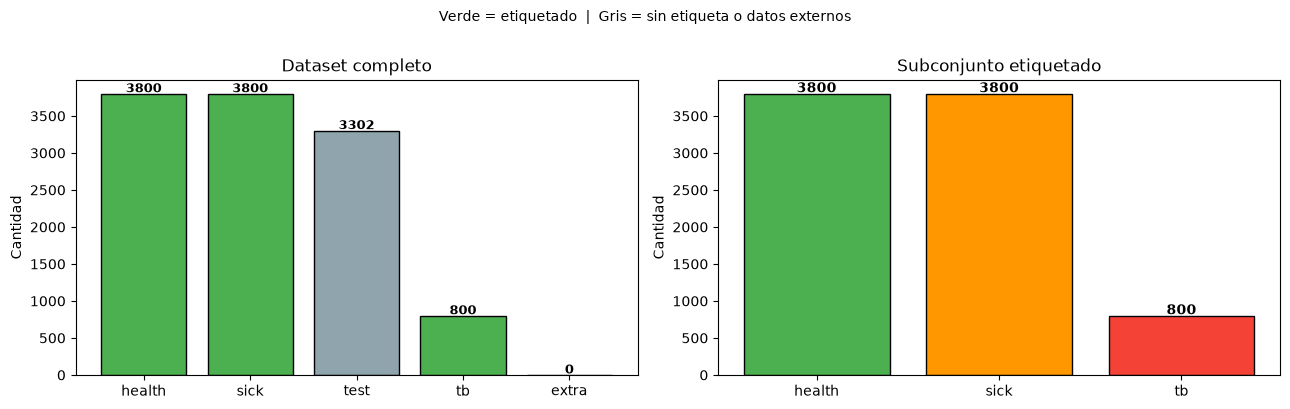

Modos de color:
modo
RGB    8400
Name: count, dtype: int64

Resoluciones:
   ancho  alto  cantidad
0    512   512      8400


In [7]:
import numpy as np

por_carpeta = resumen_df.groupby('carpeta')['imagenes'].sum().sort_values(ascending=False)
colores_barras = ['#4CAF50' if c in ['health','sick','tb'] else '#90A4AE' for c in por_carpeta.index]
counts = df_base['class_name'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bars = axes[0].bar(por_carpeta.index, por_carpeta.values, color=colores_barras, edgecolor='black')
for bar, cnt in zip(bars, por_carpeta.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 20, str(cnt), ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Dataset completo')
axes[0].set_ylabel('Cantidad')

bars2 = axes[1].bar(counts.index, counts.values, color=['#4CAF50','#FF9800','#F44336'], edgecolor='black')
for bar, cnt in zip(bars2, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, cnt + 20, str(cnt), ha='center', fontweight='bold')
axes[1].set_title('Subconjunto etiquetado')
axes[1].set_ylabel('Cantidad')

plt.suptitle('Verde = etiquetado  |  Gris = sin etiqueta o datos externos', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

print('Modos de color:')
print(df_base['modo'].value_counts())
print()
print('Resoluciones:')
print(df_base.groupby(['ancho','alto']).size().reset_index(name='cantidad').sort_values('cantidad', ascending=False).head(5))